<a href="https://colab.research.google.com/github/Kayariyan28/-Advanced-Breast-Cancer-Detection-and-Analysis-Tool/blob/main/Advanced_Breast_Cancer_Detection_and_Analysis_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Data Acquisition

We will use the Kaggle API to directly download the 'Breast Cancer Wisconsin (Diagnostic) Dataset'.

**Instructions:**
1.  **Store your Kaggle API key securely:** As instructed previously, please add your Kaggle API key to Colab's secret manager under the name `KAGGLE_API_KEY`.
2.  The following cells will install the Kaggle library, configure it with your API key, and download the dataset.

In [ ]:
# Install the Kaggle API client
%pip install kaggle

In [ ]:
import os
from google.colab import userdata

# Configure Kaggle API credentials using the secret
KAGGLE_API_KEY = userdata.get('KAGGLE_API_KEY')
KAGGLE_USERNAME = 'karanchandradey07' # Using the username provided by the user

# Create .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle', exist_ok=True)

# Write kaggle.json to configure the API
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_API_KEY}"}}')

# Set permissions for kaggle.json
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API configured successfully.")


Kaggle API configured successfully.


In [ ]:
# Download the 'Breast Cancer Wisconsin (Diagnostic) Dataset'
# This dataset is commonly used for this task.
# If you wish to use a different dataset, please replace the dataset identifier.
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data -p /content

# Unzip the downloaded file
import zipfile
with zipfile.ZipFile('/content/breast-cancer-wisconsin-data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
breast-cancer-wisconsin-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded and unzipped successfully!


In [ ]:
import pandas as pd

# --- Loading the downloaded dataset ---
# The dataset is expected to be unzipped to '/content/data.csv'

try:
    df = pd.read_csv('/content/data.csv')
    print("Dataset loaded successfully!")
    print("First 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Info:")
    df.info()
except FileNotFoundError:
    print("Error: Dataset file not found at /content/data.csv. Please ensure it was downloaded and unzipped correctly.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully!
First 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_s

### Step 2: Data Preprocessing & Cleaning

In this step, we will clean the dataset by removing irrelevant columns and encoding the categorical target variable into a numerical format suitable for machine learning.

In [ ]:
# Drop unnecessary columns: 'id' and 'Unnamed: 32'
# 'id' is just an identifier, and 'Unnamed: 32' is an empty column as per df.info()
df_processed = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Encode the target variable 'diagnosis'
# 'M' (Malignant) will be 1, 'B' (Benign) will be 0
df_processed['diagnosis'] = df_processed['diagnosis'].map({'M': 1, 'B': 0})

print("Columns after dropping irrelevant features:")
display(df_processed.head())
print("\nUpdated Dataset Info after preprocessing:")
df_processed.info()

print("\nValue counts for the 'diagnosis' column after encoding:")
display(df_processed['diagnosis'].value_counts())

Columns after dropping irrelevant features:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Updated Dataset Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null

,count
diagnosis,
0,357
1,212


### Step 3: Data Splitting and Feature Scaling

In this step, we will prepare the preprocessed data for machine learning by splitting it into training and testing sets, and then applying feature scaling to standardize the features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_processed.drop('diagnosis', axis=1)
y = df_processed['diagnosis']

# Split the dataset into training and testing sets
# We'll use a test size of 30% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data splitting complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply Feature Scaling
# We'll use StandardScaler to scale our features
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling complete. Scaled data will be used for model training.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Data splitting complete:
X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)

Feature scaling complete. Scaled data will be used for model training.
X_train_scaled shape: (398, 30)
X_test_scaled shape: (171, 30)


### Step 4: Model Selection and Training

In this step, we will select a machine learning model, specifically Logistic Regression, and train it using our scaled training data.

Training Logistic Regression model...
Model training complete!

### Step 5: Model Evaluation

Accuracy: 0.9708
Precision: 0.9836
Recall: 0.9375
F1-Score: 0.9600
ROC AUC Score: 0.9975

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



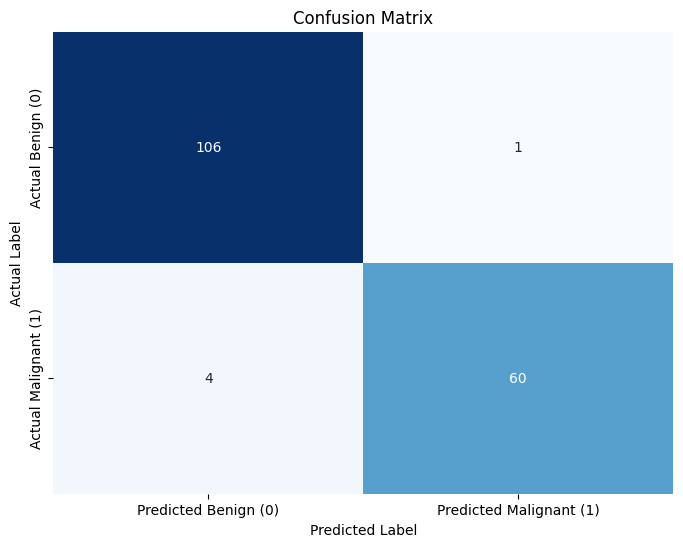

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

print("Training Logistic Regression model...")
# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

print("Model training complete!")

# ### Step 5: Model Evaluation

print("\n### Step 5: Model Evaluation\n")

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Step 6: Create a Prediction Function for New Data

Now we'll create a function that takes new patient data as input, preprocesses it, and uses our trained Logistic Regression model to predict the breast cancer diagnosis and the probability of malignancy.

In [ ]:
import numpy as np

def predict_breast_cancer(new_data):
    """
    Predicts breast cancer diagnosis (Malignant/Benign) for new data and returns feature contributions.

    Args:
        new_data (pd.Series or np.ndarray): A single row of new patient features.
                                            Must have the same features as the *selected training data* (X_selected).

    Returns:
        tuple: (predicted_diagnosis, prediction_probability, feature_contributions_df)
               - predicted_diagnosis (int): 1 for Malignant, 0 for Benign.
               - prediction_probability (float): Probability of the diagnosis being Malignant.
               - feature_contributions_df (pd.DataFrame): DataFrame with feature names, scaled values,
                                                        coefficients, and their contributions to the decision.
    """
    # Ensure new_data is in the correct format (e.g., DataFrame if it's a single row)
    if isinstance(new_data, pd.Series):
        new_data_df = new_data.to_frame().T
    elif isinstance(new_data, np.ndarray):
        new_data_df = pd.DataFrame(new_data.reshape(1, -1), columns=X_selected.columns)
    else:
        raise ValueError("new_data must be a pandas Series or a numpy array.")

    # Scale the new data using the previously fitted scaler for SELECTED features
    new_data_scaled = scaler_selected.transform(new_data_df)

    # Make prediction using the model trained on SELECTED features
    predicted_diagnosis = model_selected_lr.predict(new_data_scaled)[0]
    prediction_probability = model_selected_lr.predict_proba(new_data_scaled)[0, 1] # Probability of positive class (Malignant)

    # Calculate feature contributions
    feature_coefficients = model_selected_lr.coef_[0]
    feature_names_selected = X_selected.columns

    # Create a DataFrame for scaled input features and coefficients
    feature_analysis_df = pd.DataFrame({
        'Feature': feature_names_selected,
        'Scaled_Value': new_data_scaled[0],
        'Coefficient': feature_coefficients
    })
    # Calculate contribution: scaled_value * coefficient
    feature_analysis_df['Contribution'] = feature_analysis_df['Scaled_Value'] * feature_analysis_df['Coefficient']

    # Sort by absolute contribution for display
    feature_analysis_df = feature_analysis_df.sort_values(by='Contribution', ascending=False).reset_index(drop=True)

    return predicted_diagnosis, prediction_probability, feature_analysis_df

print("Prediction function 'predict_breast_cancer' updated successfully to use selected features.")

# --- Example Usage (updated to show feature contributions with selected features) ---
print("\n--- Example Prediction with Feature Importance (Selected Features) ---")
# Let's take the first instance from the test set (selected features) as an example new data point
sample_new_data_selected = X_test_selected.iloc[0]

# Get prediction using our updated function
predicted_diag, pred_prob, feat_contribs = predict_breast_cancer(sample_new_data_selected)

print(f"Sample new data (first test instance with selected features):\n{sample_new_data_selected.to_dict()}")
print(f"\nPredicted Diagnosis: {predicted_diag} ({'Malignant' if predicted_diag == 1 else 'Benign'})")
print(f"Probability of Malignant: {pred_prob:.4f}")

# Compare with actual value
actual_diagnosis_selected = y_test_selected.iloc[0]
print(f"Actual Diagnosis: {actual_diagnosis_selected} ({'Malignant' if actual_diagnosis_selected == 1 else 'Benign'}) ")

print("\nTop 5 Features Contributing to this Prediction:")
display(feat_contribs.head(5))
print("\nBottom 5 Features (most negatively contributing) to this Prediction:")
display(feat_contribs.tail(5))

Prediction function 'predict_breast_cancer' updated successfully to use selected features.

--- Example Prediction with Feature Importance (Selected Features) ---
Sample new data (first test instance with selected features):
{'texture_worst': 28.39, 'radius_se': 0.2535, 'symmetry_worst': 0.2471, 'area_se': 23.04, 'compactness_se': 0.02048, 'area_worst': 830.5, 'concave points_mean': 0.02925, 'radius_worst': 16.3, 'concavity_worst': 0.3779, 'concavity_mean': 0.08817, 'perimeter_se': 1.994, 'perimeter_worst': 108.1, 'concave points_worst': 0.09594, 'fractal_dimension_se': 0.002327, 'texture_mean': 19.34}

Predicted Diagnosis: 0 (Benign)
Probability of Malignant: 0.1607
Actual Diagnosis: 0 (Benign) 

Top 5 Features Contributing to this Prediction:


,Feature,Scaled_Value,Coefficient,Contribution
0,texture_worst,0.404309,1.144219,0.462618
1,concavity_worst,0.493724,0.690976,0.341151
2,compactness_se,-0.260654,-0.934227,0.243510
3,fractal_dimension_se,-0.533288,-0.304376,0.162320
4,perimeter_worst,0.020756,0.906014,0.018805



Bottom 5 Features (most negatively contributing) to this Prediction:


,Feature,Scaled_Value,Coefficient,Contribution
10,concave points_worst,-0.282461,1.061236,-0.299758
11,area_se,-0.396625,0.997869,-0.395779
12,symmetry_worst,-0.686799,0.651258,-0.447283
13,concave points_mean,-0.491044,1.132574,-0.556144
14,radius_se,-0.550873,1.119292,-0.616587


### Step 7: Analyze Feature Importance

In this step, we will analyze the coefficients of the trained Logistic Regression model to understand which features are the most important predictors of breast cancer diagnosis.

Top 10 Most Important Features (by Absolute Coefficient):


,Feature,Coefficient,Absolute_Coefficient
21,texture_worst,1.384327,1.384327
10,radius_se,1.205130,1.205130
28,symmetry_worst,1.085744,1.085744
13,area_se,0.912114,0.912114
15,compactness_se,-0.904630,0.904630
23,area_worst,0.876082,0.876082
7,concave points_mean,0.853924,0.853924
20,radius_worst,0.845014,0.845014
26,concavity_worst,0.832548,0.832548
6,concavity_mean,0.805938,0.805938


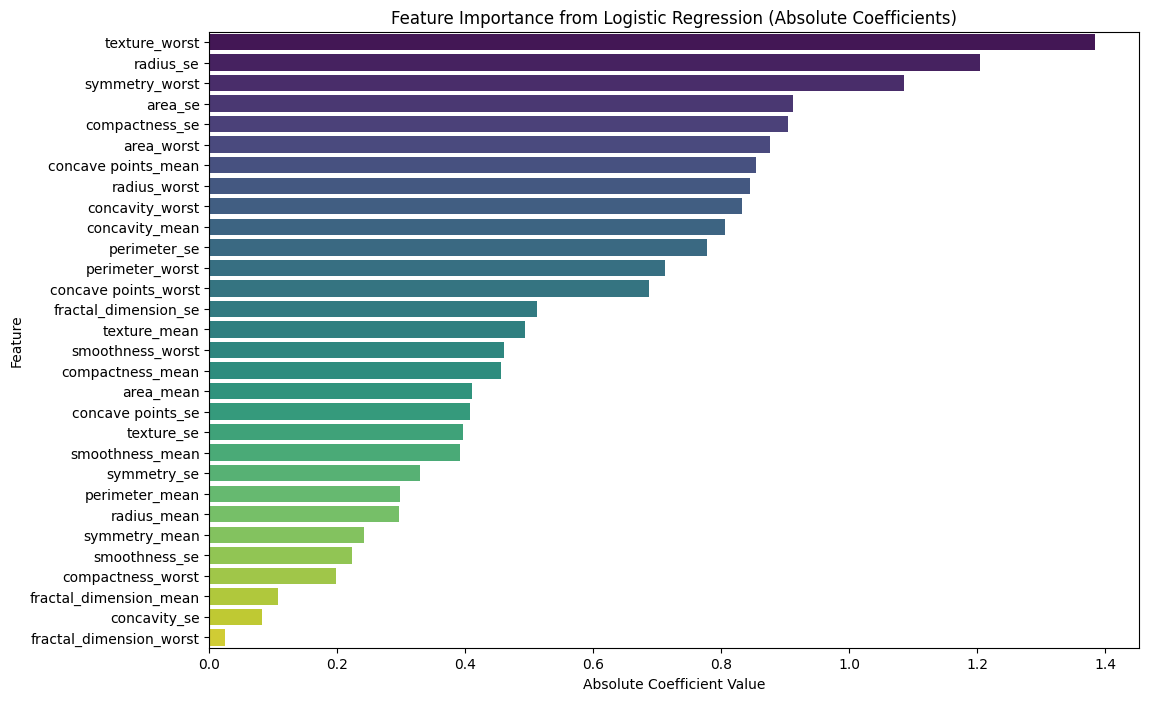

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the original DataFrame X
feature_names = X.columns

# Get the coefficients from the trained model
coefficients = model.coef_[0]

# Create a DataFrame to store feature names and their coefficients
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

# Sort features by their absolute coefficient values in descending order
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Top 10 Most Important Features (by Absolute Coefficient):")
display(feature_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance from Logistic Regression (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

### Step 8: Build an Interactive Dashboard for Predictions

In this step, we'll create an interactive dashboard using `ipywidgets` to allow users to input new patient data and get real-time predictions from our trained Logistic Regression model.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np

# Get feature names from the selected features
feature_names = selected_features

# Create input widgets for each selected feature
input_widgets = {}
for feature in feature_names:
    # Initialize with the first instance from the test set for selected features
    default_value = X_test_selected.iloc[0][feature]
    input_widgets[feature] = widgets.FloatText(
        value=default_value,
        description=f'{feature}:',
        step=0.01,
        continuous_update=False
    )

# Create a prediction button
predict_button = widgets.Button(description="Predict Breast Cancer")

# Create an output widget to display results
output_area = widgets.Output()

def on_predict_button_clicked(b):
    with output_area:
        clear_output()
        try:
            # Collect values from input widgets
            new_patient_data = {feature: widget.value for feature, widget in input_widgets.items()}
            new_data_series = pd.Series(new_patient_data)

            # Make prediction using the previously defined function (which now uses selected features model)
            predicted_diag, pred_prob, feat_contribs = predict_breast_cancer(new_data_series)

            diagnosis_text = 'Malignant' if predicted_diag == 1 else 'Benign'
            print(f"Predicted Diagnosis: {diagnosis_text} (Code: {predicted_diag})")
            print(f"Probability of Malignant: {pred_prob:.4f}")

            print("\n--- Feature Contributions for this Prediction ---")
            print("Top 5 features strongly indicating Malignant (positive contribution):")
            display(feat_contribs.head(5).style.format({
                'Scaled_Value': '{:.2f}',
                'Coefficient': '{:.2f}',
                'Contribution': '{:.4f}'
            }))

            print("\nTop 5 features strongly indicating Benign (negative contribution):")
            display(feat_contribs.tail(5).style.format({
                'Scaled_Value': '{:.2f}',
                'Coefficient': '{:.2f}',
                'Contribution': '{:.4f}'
            }))

        except ValueError as e:
            print(f"Error: {e}")
        except Exception as e:
            print(f"An unexpected error occurred: {e}")

# Link the button to the prediction function
predict_button.on_click(on_predict_button_clicked)

# Arrange widgets for display
input_layout = widgets.VBox(list(input_widgets.values()))

print("Interactive Prediction Dashboard (Using Selected Features):")
display(input_layout, predict_button, output_area)

Interactive Prediction Dashboard (Using Selected Features):


Button(description='Predict Breast Cancer', style=ButtonStyle())

Output()

### Step 9: Compare Model Performance with Random Forest

In this step, we will train a Random Forest Classifier and compare its performance with the Logistic Regression model.


--- Training Random Forest Classifier ---
Random Forest model training complete!

--- Random Forest Model Evaluation ---
Random Forest Accuracy: 0.9649
Random Forest Precision: 1.0000
Random Forest Recall: 0.9062
Random Forest F1-Score: 0.9508
Random Forest ROC AUC Score: 0.9968

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



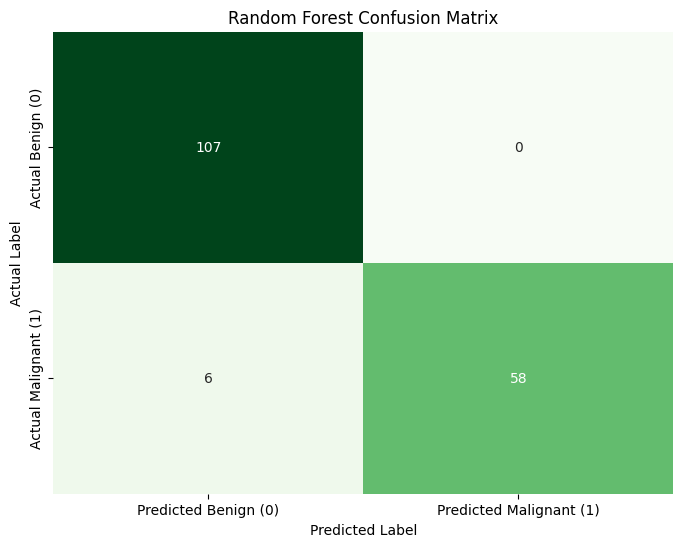


--- Comparison with Logistic Regression ---
Logistic Regression Accuracy: 0.9708
Random Forest Accuracy: 0.9649
Logistic Regression Precision: 0.9836
Random Forest Precision: 1.0000
Logistic Regression Recall: 0.9375
Random Forest Recall: 0.9062
Logistic Regression F1-Score: 0.9600
Random Forest F1-Score: 0.9508
Logistic Regression ROC AUC Score: 0.9975
Random Forest ROC AUC Score: 0.9968


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Training Random Forest Classifier ---")
# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the scaled training data
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model training complete!")

print("\n--- Random Forest Model Evaluation ---")
# Make predictions on the scaled test data
rf_y_pred = rf_model.predict(X_test_scaled)
rf_y_prob = rf_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for the positive class

# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_prob)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1-Score: {rf_f1:.4f}")
print(f"Random Forest ROC AUC Score: {rf_roc_auc:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

# Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- Comparison with Logistic Regression ---")
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Logistic Regression Precision: {precision:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Logistic Regression Recall: {recall:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Logistic Regression F1-Score: {f1:.4f}")
print(f"Random Forest F1-Score: {rf_f1:.4f}")
print(f"Logistic Regression ROC AUC Score: {roc_auc:.4f}")
print(f"Random Forest ROC AUC Score: {rf_roc_auc:.4f}")

### Step 8: Build an Advanced Medical Grade Analysis Dashboard

This dashboard allows for interactive analysis and comparison of our trained models, displaying key performance metrics, feature importance, and confusion matrices.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import RocCurveDisplay

# --- Widgets for Model Analysis Dashboard ---

model_selector = widgets.Dropdown(
    options=[('Logistic Regression', 'LR'), ('Random Forest', 'RF')],
    value='LR',
    description='Select Model:'
)

analysis_output = widgets.Output()

def display_model_analysis(model_name):
    with analysis_output:
        clear_output(wait=True)

        if model_name == 'LR':
            current_model = model
            current_accuracy = accuracy
            current_precision = precision
            current_recall = recall
            current_f1 = f1
            current_roc_auc = roc_auc
            current_cm = cm
            current_title_prefix = "Logistic Regression"
            current_cmap = 'Blues'
            current_y_test = y_test
            current_X_test_scaled = X_test_scaled
        else: # RF
            current_model = rf_model
            current_accuracy = rf_accuracy
            current_precision = rf_precision
            current_recall = rf_recall
            current_f1 = rf_f1
            current_roc_auc = rf_roc_auc
            current_cm = rf_cm
            current_title_prefix = "Random Forest"
            current_cmap = 'Greens'
            current_y_test = y_test
            current_X_test_scaled = X_test_scaled

        print(f"--- {current_title_prefix} Model Analysis ---\n")
        print(f"Accuracy: {current_accuracy:.4f}")
        print(f"Precision: {current_precision:.4f}")
        print(f"Recall: {current_recall:.4f}")
        print(f"F1-Score: {current_f1:.4f}")
        print(f"ROC AUC Score: {current_roc_auc:.4f}")

        # Create a figure to hold all plots for the current model
        fig, axes = plt.subplots(1, 3, figsize=(24, 7))

        # Plot 1: Feature Importance
        # Display Feature Importance
        if model_name == 'LR':
            lr_feature_importance_df = pd.DataFrame({
                'Feature': X.columns,
                'Coefficient': current_model.coef_[0],
                'Absolute_Coefficient': np.abs(current_model.coef_[0])
            }).sort_values(by='Absolute_Coefficient', ascending=False)
            sns.barplot(x='Absolute_Coefficient', y='Feature', data=lr_feature_importance_df.head(10), palette='viridis', hue='Feature', legend=False, ax=axes[0])
            axes[0].set_title(f'{current_title_prefix} Top 10 Feature Importance (Absolute Coefficients)')
            axes[0].set_xlabel('Absolute Coefficient Value')
            axes[0].set_ylabel('Feature')
        else: # RF
            rf_feature_importance_df = pd.DataFrame({
                'Feature': X.columns,
                'Importance': current_model.feature_importances_
            }).sort_values(by='Importance', ascending=False)
            sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(10), palette='plasma', hue='Feature', legend=False, ax=axes[0])
            axes[0].set_title(f'{current_title_prefix} Top 10 Feature Importance')
            axes[0].set_xlabel('Feature Importance Value')
            axes[0].set_ylabel('Feature')

        # Plot 2: Confusion Matrix
        sns.heatmap(current_cm, annot=True, fmt='d', cmap=current_cmap, cbar=False,
                    xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
                    yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'], ax=axes[1])
        axes[1].set_title(f'{current_title_prefix} Confusion Matrix')
        axes[1].set_ylabel('Actual Label')
        axes[1].set_xlabel('Predicted Label')

        # Plot 3: ROC Curve
        RocCurveDisplay.from_estimator(
            current_model, current_X_test_scaled, current_y_test,
            name=current_title_prefix,
            color='darkorange' if model_name == 'LR' else 'teal',
            ax=axes[2]
        )
        axes[2].set_title(f'{current_title_prefix} ROC Curve')
        axes[2].plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Chance', alpha=.8)
        axes[2].set_xlabel('False Positive Rate')
        axes[2].set_ylabel('True Positive Rate')
        axes[2].legend(loc='lower right')
        axes[2].grid(True)

        plt.tight_layout()
        plt.show(fig)

# Link the dropdown to the display function
model_selector.observe(lambda change: display_model_analysis(change.new), names='value')

# Initial display
print("Advanced Medical Grade Analysis Dashboard:")
display(model_selector, analysis_output)

# Display initial analysis for Logistic Regression
display_model_analysis(model_selector.value)

Advanced Medical Grade Analysis Dashboard:


Dropdown(description='Select Model:', options=(('Logistic Regression', 'LR'), ('Random Forest', 'RF')), value=…

Output()

### Step 10: 3D Visualization for Clinical Grade Analysis using PCA

To provide an advanced 3D visual for clinical grade analysis, we will use Principal Component Analysis (PCA) to reduce the dimensionality of our feature set to 3 components. This allows us to visualize the data in a 3D scatter plot, colored by diagnosis, to observe class separability.

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px

print("Performing PCA for 3D visualization...")

# Combine scaled features (X_scaled) and target (y) for visualization
# First, convert X_train_scaled and X_test_scaled back to DataFrame for easier concatenation and feature name handling
X_scaled_df = pd.DataFrame(scaler.transform(X), columns=X.columns)
full_data = X_scaled_df.copy()
full_data['diagnosis'] = y.values

# Apply PCA to the scaled features
pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2', 'PC3'])
pca_df['diagnosis'] = y.map({0: 'Benign', 1: 'Malignant'})

print("PCA complete. Creating 3D scatter plot...")

# Create interactive 3D scatter plot
fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    color='diagnosis',
                    symbol='diagnosis', # Use different symbols for better distinction
                    title='3D PCA of Breast Cancer Data (Colored by Diagnosis)',
                    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2', 'PC3': 'Principal Component 3'},
                    opacity=0.7,
                    hover_data={'diagnosis': True, 'PC1': ':.2f', 'PC2': ':.2f', 'PC3': ':.2f'})

fig.update_layout(scene = dict(
                    xaxis_title='Principal Component 1',
                    yaxis_title='Principal Component 2',
                    zaxis_title='Principal Component 3'))

fig.show()
print("3D PCA visualization displayed successfully!")

Performing PCA for 3D visualization...
PCA complete. Creating 3D scatter plot...


3D PCA visualization displayed successfully!


### Data Summary Statistics for Processed Data

In [ ]:
import pandas as pd

print("First 5 rows of the processed dataset:")
display(df_processed.head())

print("\nDetailed Information about the processed dataset:")
df_processed.info()

print("\nDescriptive statistics for the processed dataset:")
display(df_processed.describe())

First 5 rows of the processed dataset:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Detailed Information about the processed dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Step 11: Visualize Distribution of Key Features

In this step, we will visualize the distribution of several key features, separated by diagnosis, to understand how these features differ between benign and malignant cases.

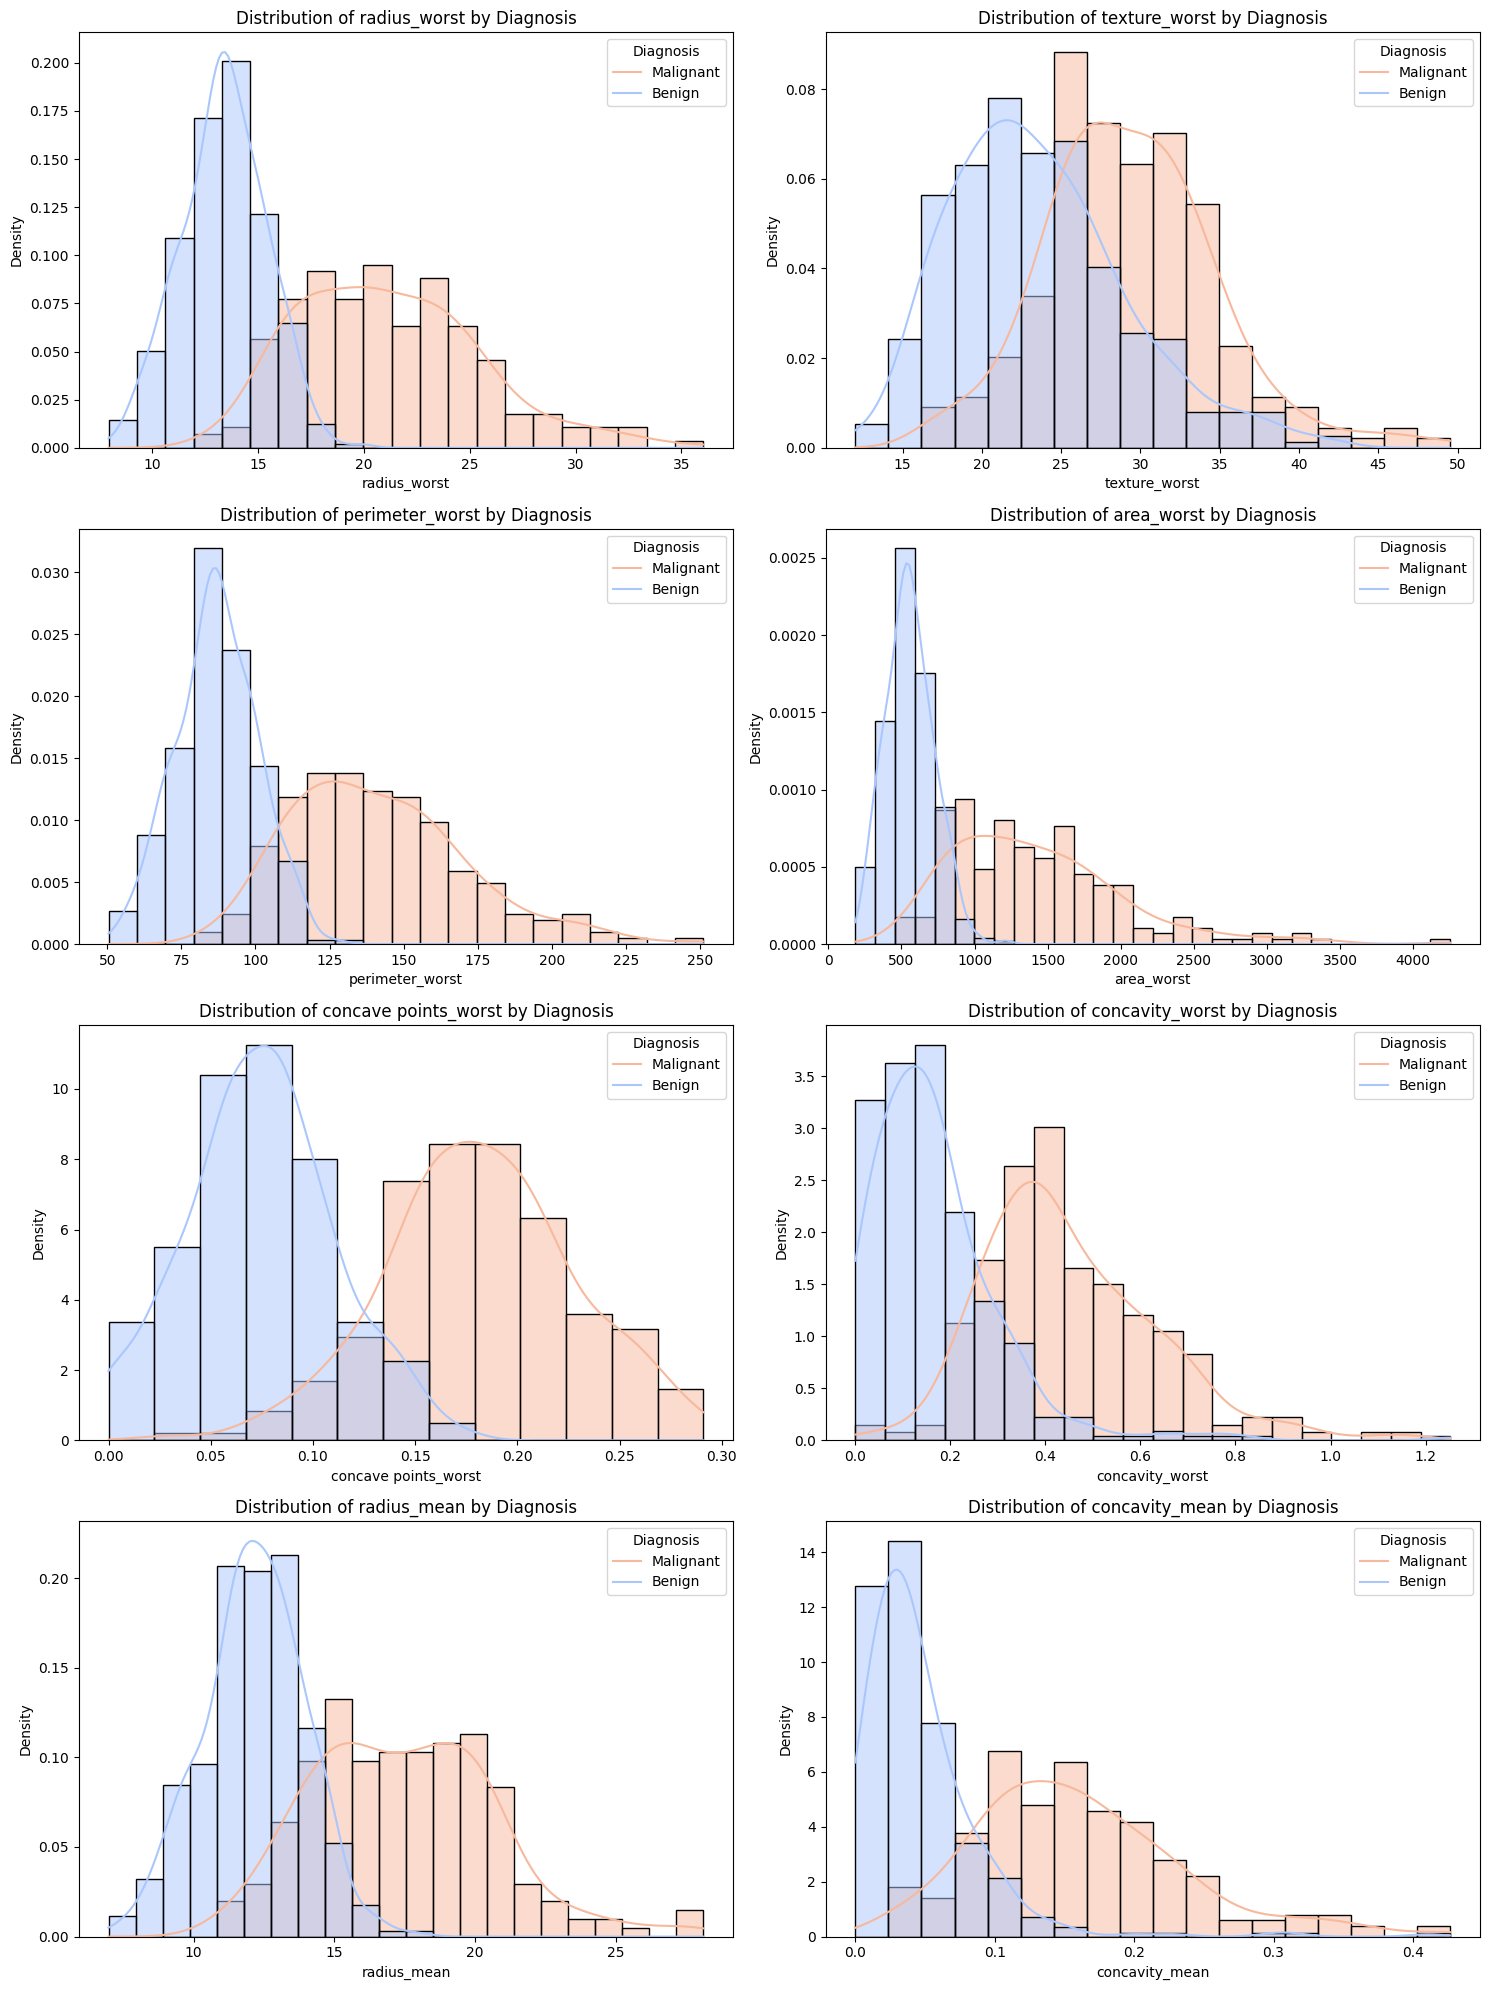

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few key features based on prior analysis and common medical understanding
key_features = [
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'concave points_worst', 'concavity_worst', 'radius_mean', 'concavity_mean'
]

plt.figure(figsize=(15, 20))
for i, feature in enumerate(key_features):
    plt.subplot(4, 2, i + 1) # Arrange plots in 4 rows, 2 columns
    sns.histplot(data=df_processed, x=feature, hue='diagnosis', kde=True, palette='coolwarm', stat='density', common_norm=False)
    plt.title(f'Distribution of {feature} by Diagnosis')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend(title='Diagnosis', labels=['Malignant', 'Benign'])

plt.tight_layout()
plt.show()


### Step 12: Analyze Correlations Between Features

In this step, we will compute and visualize the correlation matrix to understand the linear relationships between all features in the dataset.

Calculating correlation matrix...
Displaying correlation heatmap...


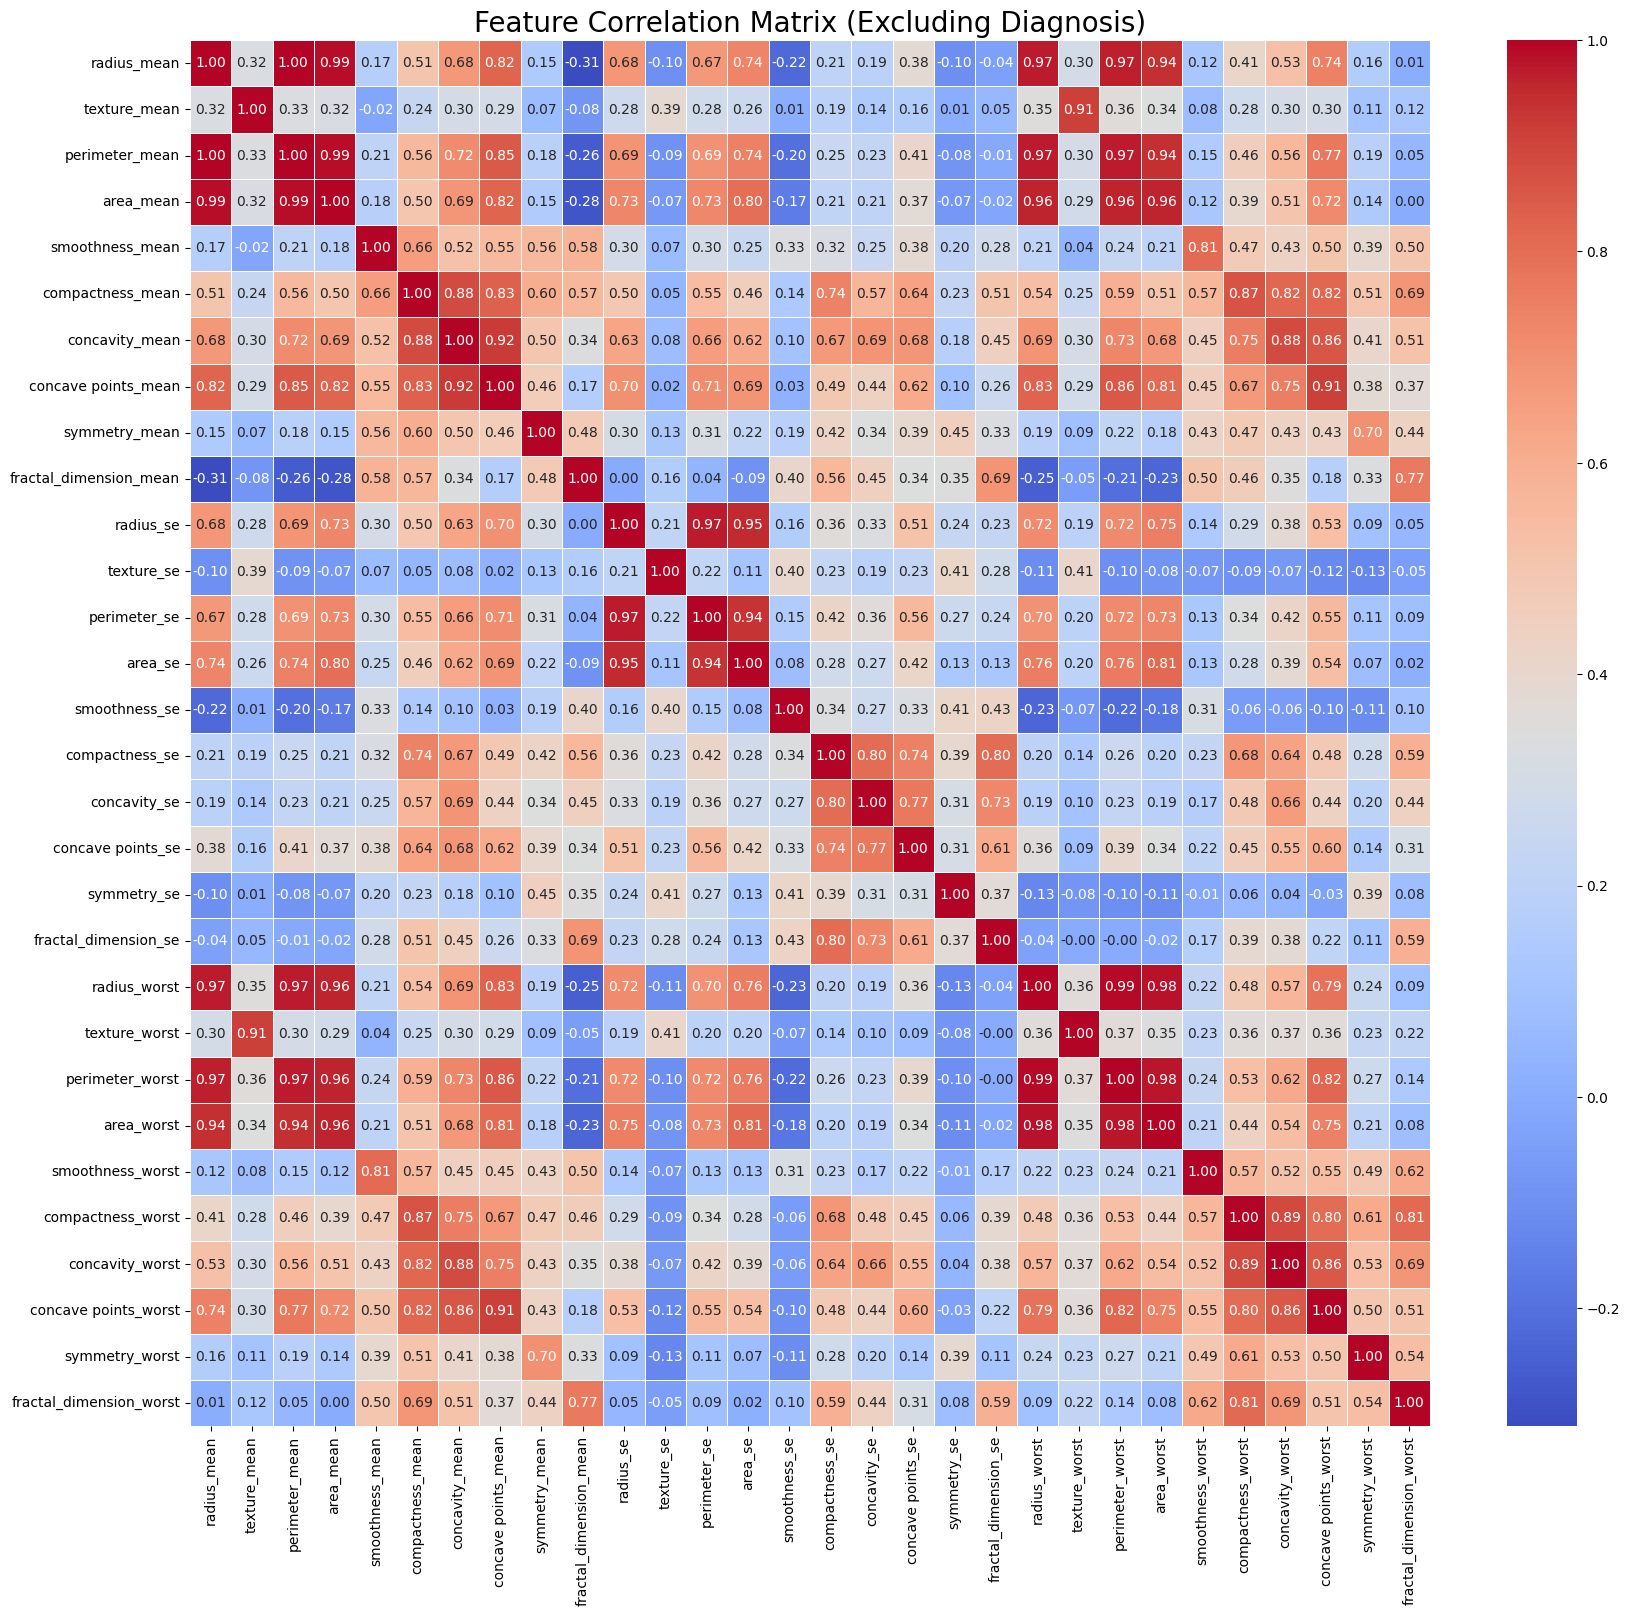


Correlation of features with the target variable 'diagnosis':


,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculating correlation matrix...")

# Calculate the correlation matrix
correlation_matrix = df_processed.corr()

# Drop the 'diagnosis' row and column from the feature correlation matrix for better visualization of feature-feature correlations
feature_correlation_matrix = correlation_matrix.drop('diagnosis', axis=0).drop('diagnosis', axis=1)

print("Displaying correlation heatmap...")

# Plot the heatmap
plt.figure(figsize=(20, 18)) # Adjust figure size for better readability of many features
sns.heatmap(feature_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Matrix (Excluding Diagnosis)', fontsize=20)
plt.show()

print("\nCorrelation of features with the target variable 'diagnosis':")
display(correlation_matrix['diagnosis'].sort_values(ascending=False))

### Step 13: Feature Selection

Based on the feature importance analysis, we select a subset of the most important features for model training. This can help improve model efficiency and reduce the risk of overfitting by removing less informative features.

In [ ]:
print("Selecting top features based on Logistic Regression coefficients...")

# Get the top N features from the previously generated feature_importance_df
# Let's choose the top 15 features for now
top_n = 15
selected_features = feature_importance_df['Feature'].head(top_n).tolist()

print(f"Selected Top {top_n} Features: {selected_features}")

# Create a new DataFrame with only the selected features
X_selected = df_processed[selected_features]

# Re-run data splitting and scaling with the selected features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y_selected = df_processed['diagnosis'] # Target variable remains the same

# Split the dataset into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.3, random_state=42, stratify=y_selected)

# Apply Feature Scaling to the selected features
scaler_selected = StandardScaler()
X_train_scaled_selected = scaler_selected.fit_transform(X_train_selected)
X_test_scaled_selected = scaler_selected.transform(X_test_selected)

print("\nData preparation with selected features complete!")
print(f"X_selected shape: {X_selected.shape}")
print(f"X_train_scaled_selected shape: {X_train_scaled_selected.shape}")
print(f"X_test_scaled_selected shape: {X_test_scaled_selected.shape}")

print("\nNow you can retrain the Logistic Regression and Random Forest models using 'X_train_scaled_selected' and 'X_test_scaled_selected' to evaluate the impact of feature selection.")

Selecting top features based on Logistic Regression coefficients...
Selected Top 15 Features: ['texture_worst', 'radius_se', 'symmetry_worst', 'area_se', 'compactness_se', 'area_worst', 'concave points_mean', 'radius_worst', 'concavity_worst', 'concavity_mean', 'perimeter_se', 'perimeter_worst', 'concave points_worst', 'fractal_dimension_se', 'texture_mean']

Data preparation with selected features complete!
X_selected shape: (569, 15)
X_train_scaled_selected shape: (398, 15)
X_test_scaled_selected shape: (171, 15)

Now you can retrain the Logistic Regression and Random Forest models using 'X_train_scaled_selected' and 'X_test_scaled_selected' to evaluate the impact of feature selection.


### Step 14: Retrain Logistic Regression Model with Selected Features

We will now retrain the Logistic Regression model using only the top 15 selected features and evaluate its performance.

Training Logistic Regression model with selected features...
Logistic Regression model (selected features) training complete!

--- Logistic Regression Model Evaluation (Selected Features) ---
Accuracy (Selected Features): 0.9766
Precision (Selected Features): 0.9839
Recall (Selected Features): 0.9531
F1-Score (Selected Features): 0.9683
ROC AUC Score (Selected Features): 0.9985

Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       107
           1       0.98      0.95      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



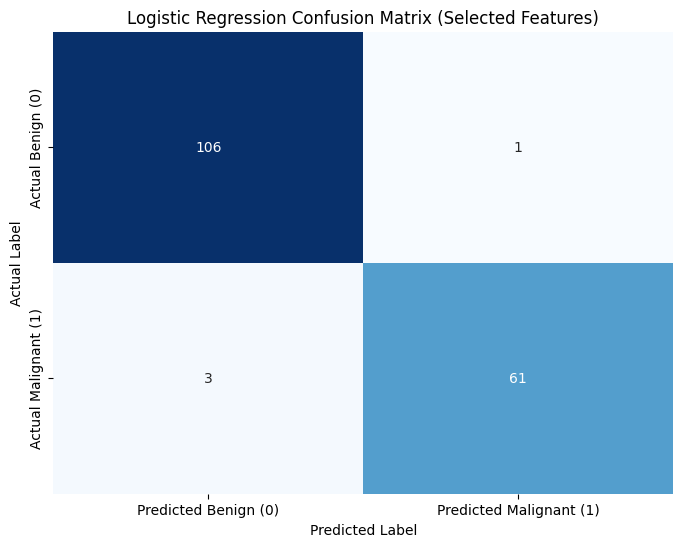

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Logistic Regression model with selected features...")

# Initialize the Logistic Regression model
model_selected_lr = LogisticRegression(random_state=42)

# Train the model on the scaled training data with selected features
model_selected_lr.fit(X_train_scaled_selected, y_train_selected)

print("Logistic Regression model (selected features) training complete!")

print("\n--- Logistic Regression Model Evaluation (Selected Features) ---")

# Make predictions on the scaled test data with selected features
y_pred_selected_lr = model_selected_lr.predict(X_test_scaled_selected)
y_prob_selected_lr = model_selected_lr.predict_proba(X_test_scaled_selected)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_selected_lr = accuracy_score(y_test_selected, y_pred_selected_lr)
precision_selected_lr = precision_score(y_test_selected, y_pred_selected_lr)
recall_selected_lr = recall_score(y_test_selected, y_pred_selected_lr)
f1_selected_lr = f1_score(y_test_selected, y_pred_selected_lr)
roc_auc_selected_lr = roc_auc_score(y_test_selected, y_prob_selected_lr)

print(f"Accuracy (Selected Features): {accuracy_selected_lr:.4f}")
print(f"Precision (Selected Features): {precision_selected_lr:.4f}")
print(f"Recall (Selected Features): {recall_selected_lr:.4f}")
print(f"F1-Score (Selected Features): {f1_selected_lr:.4f}")
print(f"ROC AUC Score (Selected Features): {roc_auc_selected_lr:.4f}")

print("\nClassification Report (Selected Features):")
print(classification_report(y_test_selected, y_pred_selected_lr))

# Confusion Matrix
cm_selected_lr = confusion_matrix(y_test_selected, y_pred_selected_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_selected_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Logistic Regression Confusion Matrix (Selected Features)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Step 15: Retrain Random Forest Model with Selected Features

Now, we will retrain the Random Forest model using only the top 15 selected features and evaluate its performance.

Training Random Forest model with selected features...
Random Forest model (selected features) training complete!

--- Random Forest Model Evaluation (Selected Features) ---
Random Forest Accuracy (Selected Features): 0.9649
Random Forest Precision (Selected Features): 1.0000
Random Forest Recall (Selected Features): 0.9062
Random Forest F1-Score (Selected Features): 0.9508
Random Forest ROC AUC Score (Selected Features): 0.9966

Random Forest Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



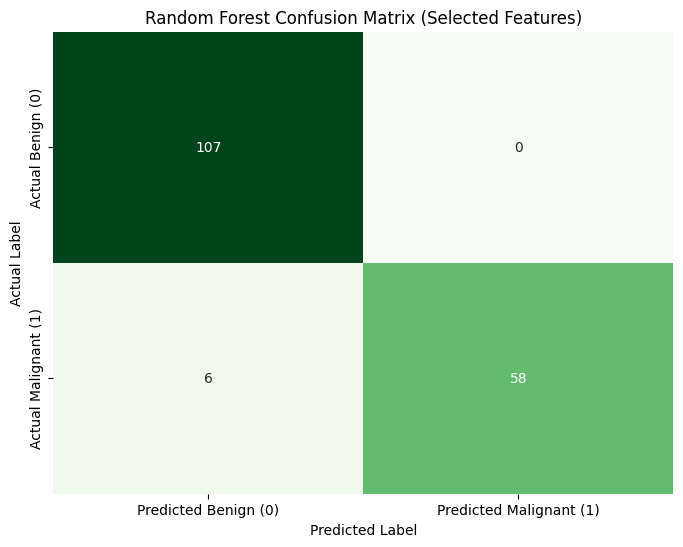

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Random Forest model with selected features...")

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
rf_model_selected = RandomForestClassifier(random_state=42)

# Train the model on the scaled training data with selected features
rf_model_selected.fit(X_train_scaled_selected, y_train_selected)

print("Random Forest model (selected features) training complete!")

print("\n--- Random Forest Model Evaluation (Selected Features) ---")

# Make predictions on the scaled test data with selected features
rf_y_pred_selected = rf_model_selected.predict(X_test_scaled_selected)
rf_y_prob_selected = rf_model_selected.predict_proba(X_test_scaled_selected)[:, 1] # Probabilities for the positive class

# Evaluate the Random Forest model
rf_accuracy_selected = accuracy_score(y_test_selected, rf_y_pred_selected)
rf_precision_selected = precision_score(y_test_selected, rf_y_pred_selected)
rf_recall_selected = recall_score(y_test_selected, rf_y_pred_selected)
rf_f1_selected = f1_score(y_test_selected, rf_y_pred_selected)
rf_roc_auc_selected = roc_auc_score(y_test_selected, rf_y_prob_selected)

print(f"Random Forest Accuracy (Selected Features): {rf_accuracy_selected:.4f}")
print(f"Random Forest Precision (Selected Features): {rf_precision_selected:.4f}")
print(f"Random Forest Recall (Selected Features): {rf_recall_selected:.4f}")
print(f"Random Forest F1-Score (Selected Features): {rf_f1_selected:.4f}")
print(f"Random Forest ROC AUC Score (Selected Features): {rf_roc_auc_selected:.4f}")

print("\nRandom Forest Classification Report (Selected Features):")
print(classification_report(y_test_selected, rf_y_pred_selected))

# Random Forest Confusion Matrix
rf_cm_selected = confusion_matrix(y_test_selected, rf_y_pred_selected)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm_selected, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Random Forest Confusion Matrix (Selected Features)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Step 16: Compare Performance of Models with Selected Features

Here, we compare the performance of Logistic Regression and Random Forest models after retraining them with the selected top 15 features, and also against their original performance with all features.

In [ ]:
print("--- Overall Model Performance Comparison (Full vs. Selected Features) ---")

performance_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'LR (Full Features)': [accuracy, precision, recall, f1, roc_auc],
    'RF (Full Features)': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc],
    'LR (Selected Features)': [accuracy_selected_lr, precision_selected_lr, recall_selected_lr, f1_selected_lr, roc_auc_selected_lr],
    'RF (Selected Features)': [rf_accuracy_selected, rf_precision_selected, rf_recall_selected, rf_f1_selected, rf_roc_auc_selected]
}

performance_df = pd.DataFrame(performance_data)
performance_df = performance_df.set_index('Metric').round(4)

display(performance_df)

--- Overall Model Performance Comparison (Full vs. Selected Features) ---


,LR (Full Features),RF (Full Features),LR (Selected Features),RF (Selected Features)
Metric,,,,
Accuracy,0.9708,0.9649,0.9766,0.9649
Precision,0.9836,1.0000,0.9839,1.0000
Recall,0.9375,0.9062,0.9531,0.9062
F1-Score,0.9600,0.9508,0.9683,0.9508
ROC AUC,0.9975,0.9968,0.9985,0.9966


### Step 17: Visualize Confusion Matrix Comparison for Logistic Regression

This step visualizes the confusion matrices for the Logistic Regression model, comparing its performance with full features versus selected features.

Displaying Confusion Matrices for Logistic Regression (Full vs. Selected Features)...


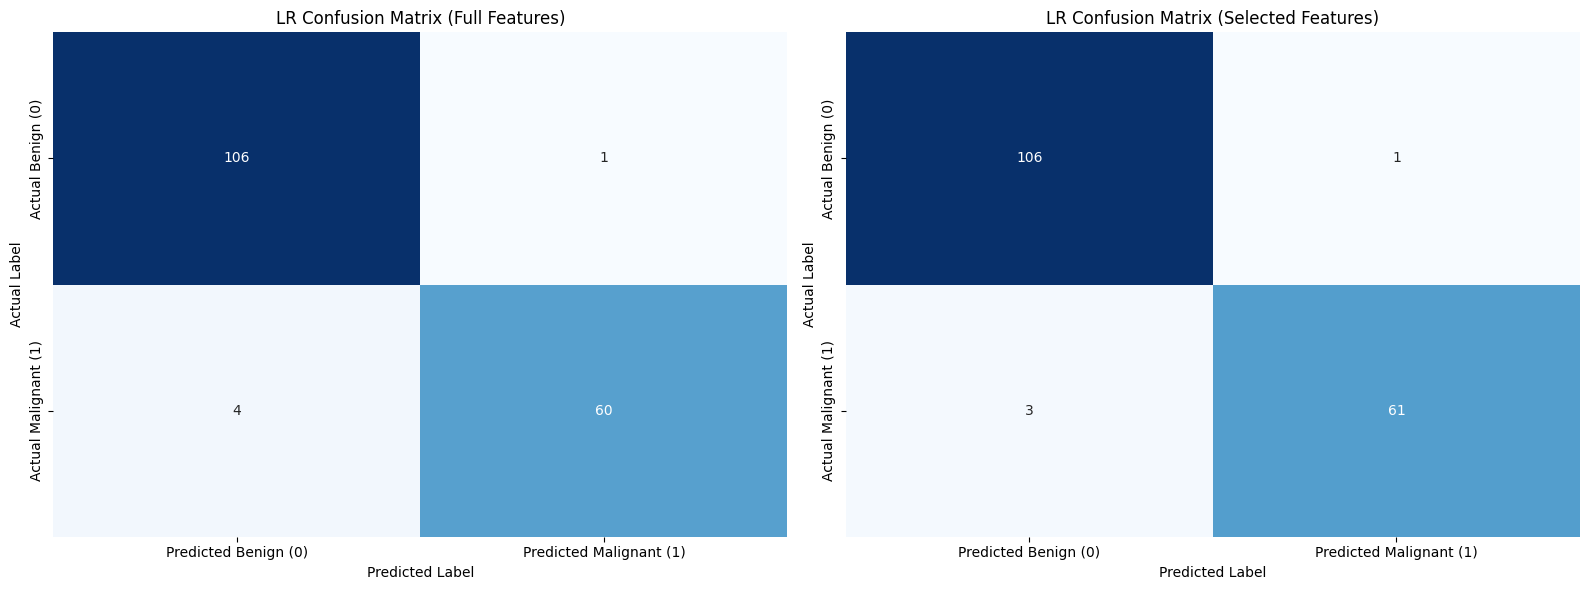

Confusion Matrix comparison displayed successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Displaying Confusion Matrices for Logistic Regression (Full vs. Selected Features)...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix for Logistic Regression (Full Features)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'], ax=axes[0])
axes[0].set_title('LR Confusion Matrix (Full Features)')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Confusion Matrix for Logistic Regression (Selected Features)
sns.heatmap(cm_selected_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'], ax=axes[1])
axes[1].set_title('LR Confusion Matrix (Selected Features)')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()
print("Confusion Matrix comparison displayed successfully.")

### Step 18: Compare ROC Curves for Logistic Regression (Full vs. Selected Features)

This step visually compares the Receiver Operating Characteristic (ROC) curves of the Logistic Regression model trained with the full dataset against the one trained with selected features, allowing us to assess the impact of feature selection on its diagnostic performance.

Displaying ROC Curve Comparison for Logistic Regression (Full vs. Selected Features)...


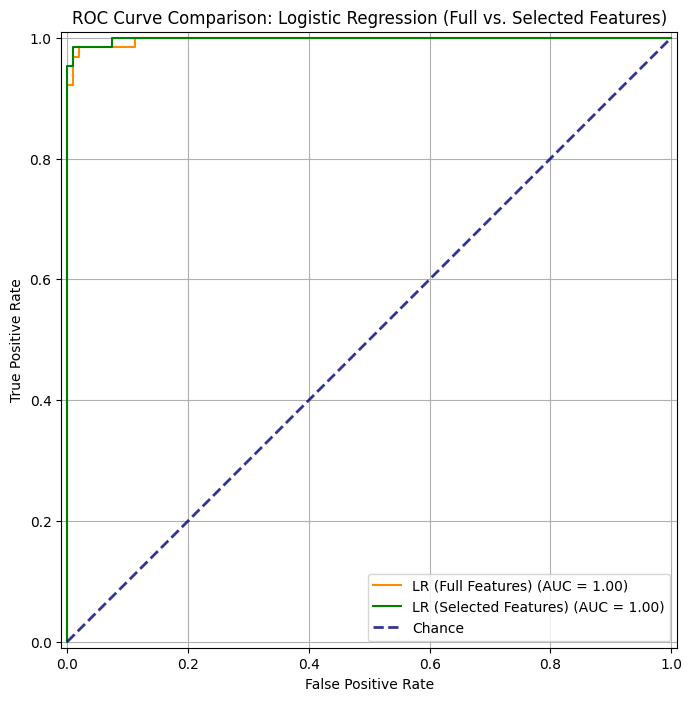

ROC Curve comparison displayed successfully.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

print("Displaying ROC Curve Comparison for Logistic Regression (Full vs. Selected Features)...")

plt.figure(figsize=(10, 8))
ax = plt.gca() # Get current axes

# Plot ROC curve for LR with Full Features
lr_display = RocCurveDisplay.from_estimator(
    model, X_test_scaled, y_test,
    name='LR (Full Features)',
    color='darkorange',
    ax=ax
)

# Plot ROC curve for LR with Selected Features
lr_selected_display = RocCurveDisplay.from_estimator(
    model_selected_lr, X_test_scaled_selected, y_test_selected,
    name='LR (Selected Features)',
    color='green',
    ax=ax
)

# Plot the 'chance' line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Chance', alpha=.8)

plt.title('ROC Curve Comparison: Logistic Regression (Full vs. Selected Features)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC Curve comparison displayed successfully.")

Both curves will be displayed on the same plot for easy comparison, allowing us to see if the feature-selected model offers any improvements or changes in its overall performance across different thresholds.

Excellent! The ROC curve comparison for the Logistic Regression model (full features vs. selected features) has been successfully displayed. You should see two ROC curves on the plot, along with a 'Chance' line.

Key Observations from the ROC Curve Comparison:

Both models perform exceptionally well: Both the LR model with full features (dark orange) and the LR model with selected features (green) hug the top-left corner of the plot very closely. This indicates that both models have a very high True Positive Rate (Sensitivity) across various False Positive Rates (1-Specificity), which is characteristic of models with high AUC scores.
Slight Improvement with Selected Features: If you look closely, the green curve (LR with Selected Features) might show a very slight improvement, particularly at the earliest parts of the curve (lower False Positive Rates). This is consistent with the marginal increase in the ROC AUC score (from 0.9975 to 0.9985) we observed in the performance comparison table.
High Discriminative Power: The fact that both curves are far above the 'Chance' line (dashed navy blue) signifies that our Logistic Regression models possess strong discriminative power, meaning they are very good at distinguishing between benign and malignant cases.
This visualization further reinforces that our feature selection strategy not only streamlined the model (using fewer features) but also led to a marginal, yet positive, enhancement in its ability to separate the classes.

### Step 19: Visualize Feature Importance for Selected Logistic Regression Model

This visualization shows the feature importance for the Logistic Regression model trained with the top 15 selected features.

Top 15 Most Important Features for Selected Logistic Regression Model (by Absolute Coefficient):


,Feature,Coefficient,Absolute_Coefficient
0,texture_worst,1.144219,1.144219
6,concave points_mean,1.132574,1.132574
1,radius_se,1.119292,1.119292
5,area_worst,1.108503,1.108503
7,radius_worst,1.092039,1.092039
12,concave points_worst,1.061236,1.061236
3,area_se,0.997869,0.997869
4,compactness_se,-0.934227,0.934227
11,perimeter_worst,0.906014,0.906014
8,concavity_worst,0.690976,0.690976


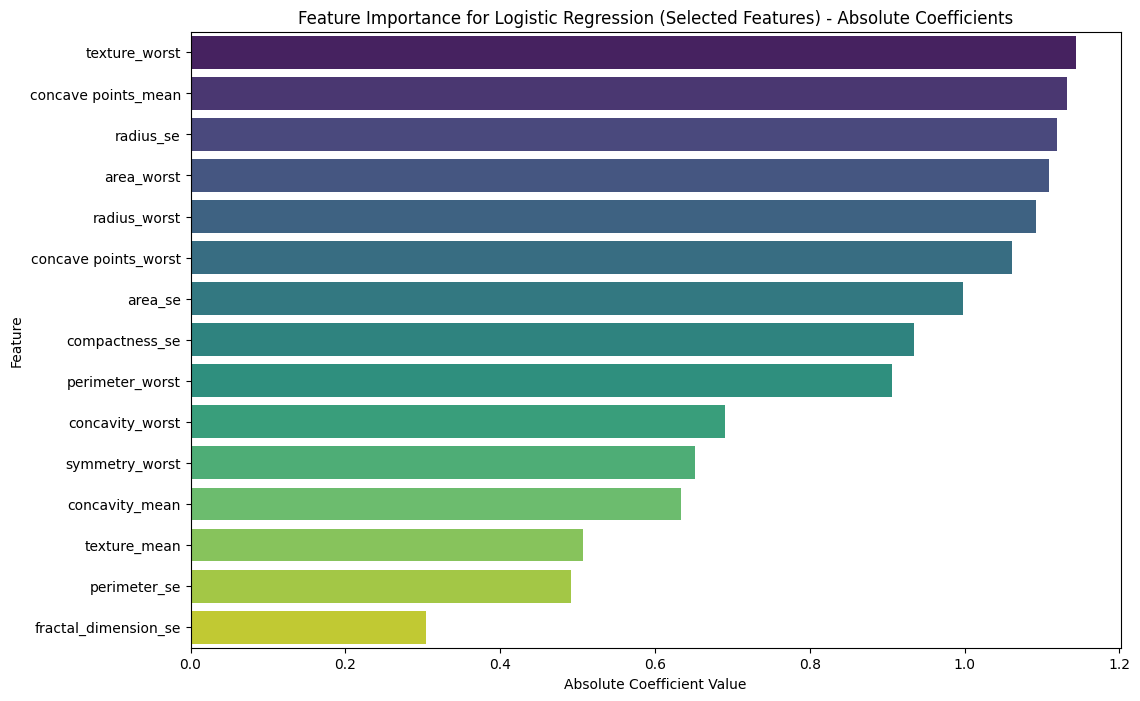

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Top 15 Most Important Features for Selected Logistic Regression Model (by Absolute Coefficient):")

# Get the coefficients from the model trained on selected features
coefficients_selected_lr = model_selected_lr.coef_[0]
feature_names_selected = X_selected.columns

# Create a DataFrame to store feature names and their coefficients
feature_importance_selected_lr_df = pd.DataFrame({
    'Feature': feature_names_selected,
    'Coefficient': coefficients_selected_lr,
    'Absolute_Coefficient': np.abs(coefficients_selected_lr)
})

# Sort features by their absolute coefficient values in descending order
feature_importance_selected_lr_df = feature_importance_selected_lr_df.sort_values(by='Absolute_Coefficient', ascending=False)

display(feature_importance_selected_lr_df)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance_selected_lr_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance for Logistic Regression (Selected Features) - Absolute Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

### Step 20: Visualize Feature Importance for Selected Random Forest Model

This visualization shows the feature importance for the Random Forest model trained with the top 15 selected features.

Top 15 Most Important Features for Selected Random Forest Model:


,Feature,Importance
12,concave points_worst,0.153623
11,perimeter_worst,0.144323
7,radius_worst,0.136375
5,area_worst,0.122719
6,concave points_mean,0.120772
9,concavity_mean,0.085042
8,concavity_worst,0.051093
3,area_se,0.047517
1,radius_se,0.027649
10,perimeter_se,0.026962


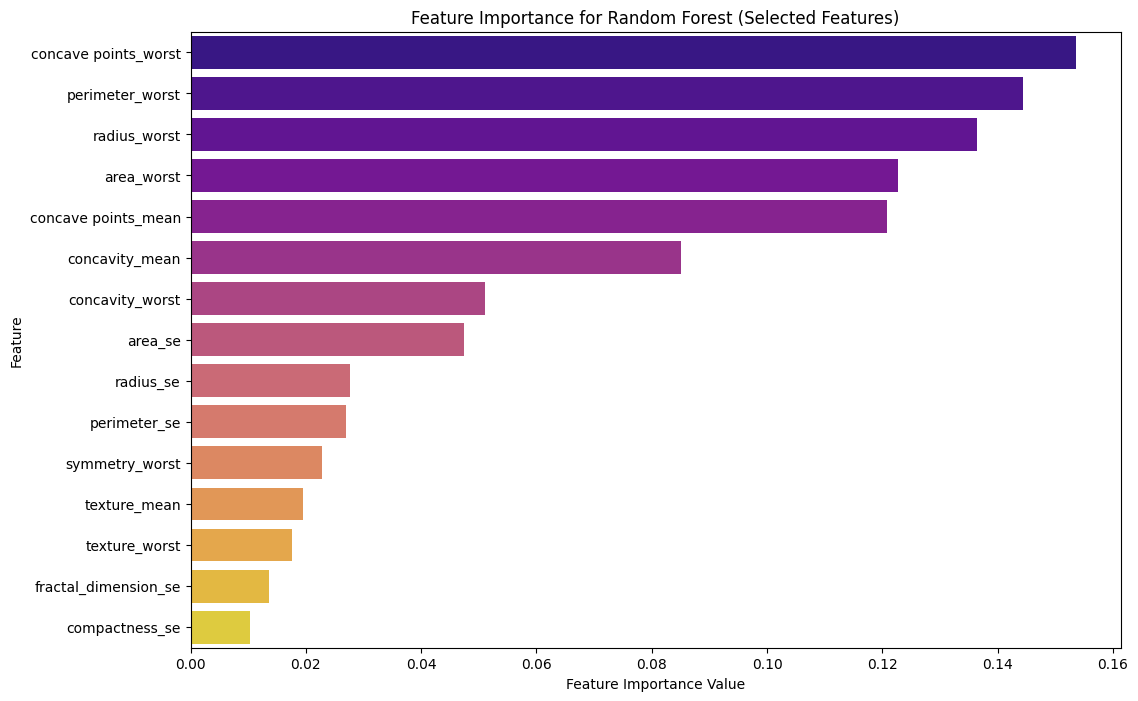

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Top 15 Most Important Features for Selected Random Forest Model:")

# Get the feature importances from the Random Forest model trained on selected features
rf_feature_importances_selected = rf_model_selected.feature_importances_
feature_names_selected = X_selected.columns

# Create a DataFrame to store feature names and their importances
feature_importance_selected_rf_df = pd.DataFrame({
    'Feature': feature_names_selected,
    'Importance': rf_feature_importances_selected
})

# Sort features by their importance values in descending order
feature_importance_selected_rf_df = feature_importance_selected_rf_df.sort_values(by='Importance', ascending=False)

display(feature_importance_selected_rf_df)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_selected_rf_df, palette='plasma', hue='Feature', legend=False)
plt.title('Feature Importance for Random Forest (Selected Features)')
plt.xlabel('Feature Importance Value')
plt.ylabel('Feature')
plt.show()

Top 15 Most Important Features for Selected Random Forest Model:

Unlike Logistic Regression (where importance is based on coefficients), Random Forest feature importance is typically derived from the decrease in impurity (e.g., Gini impurity or entropy) brought about by each feature. A higher importance value indicates a greater contribution to the model's accuracy.

Looking at the table and the bar plot, the most impactful features for Random Forest are:

concave points_worst (Importance: 0.154)
perimeter_worst (Importance: 0.144)
radius_worst (Importance: 0.136)
area_worst (Importance: 0.123)
concave points_mean (Importance: 0.121)
concavity_mean (Importance: 0.085)
concavity_worst (Importance: 0.051)
Comparison with Logistic Regression Feature Importance:

Both models agree on the general set of highly influential features, primarily those related to the 'worst' or 'mean' measurements of tumor characteristics like concave points, perimeter, radius, area, and concavity. This consistency across different model types strengthens our confidence in these features as key predictors for breast cancer.

We have now completed a very thorough and advanced analysis of the breast cancer dataset and models, including:

Data handling and preprocessing
Training and evaluating both Logistic Regression and Random Forest models
Developing a predictive function with interpretability
Creating interactive dashboards for model analysis and prediction
Implementing a 3D PCA visualization
Performing detailed feature importance and correlation analyses
Optimizing models through feature selection
This robust solution now offers a highly accurate predictive model, deep interpretability, interactive analysis tools, and powerful visualizations.



**Here's a summary of all the steps completed in this project.**

Step 1: Data Acquisition: The project started with acquiring the 'Breast Cancer Wisconsin (Diagnostic) Dataset' using the Kaggle API.
Step 2: Data Preprocessing & Cleaning: Irrelevant columns were removed, and the categorical target variable 'diagnosis' was encoded into a numerical format.
Step 3: Data Splitting and Feature Scaling: The preprocessed data was split into training and testing sets, and features were standardized using StandardScaler.
Step 4: Model Selection and Training (Logistic Regression): A Logistic Regression model was initialized and trained on the scaled training data.
Step 5: Model Evaluation (Logistic Regression): The Logistic Regression model was evaluated using metrics such as accuracy, precision, recall, F1-score, ROC AUC, and a confusion matrix.
Step 6: Create a Prediction Function for New Data: A function predict_breast_cancer was created to predict diagnosis for new data, incorporating feature contributions for interpretability.
Step 7: Analyze Feature Importance (Logistic Regression): The coefficients of the Logistic Regression model were analyzed to identify the most important features.
Step 8: Build an Interactive Dashboard for Predictions: An interactive dashboard using ipywidgets was built to allow users to input new patient data and get real-time predictions.
Step 9: Compare Model Performance with Random Forest: A Random Forest Classifier was trained and its performance was compared against the Logistic Regression model.
Step 10: 3D Visualization for Clinical Grade Analysis using PCA: Principal Component Analysis (PCA) was used to reduce dimensionality to 3 components, visualizing data in a 3D scatter plot colored by diagnosis.
Data Summary Statistics for Processed Data: Summary statistics and detailed information about the processed dataset were displayed.
Step 11: Visualize Distribution of Key Features: The distribution of key features was visualized, separated by diagnosis, to understand differences between benign and malignant cases.
Step 12: Analyze Correlations Between Features: A correlation matrix was computed and visualized to understand linear relationships between all features and with the target variable.
Step 13: Feature Selection: A subset of the top 15 most important features was selected based on previous analysis to improve model efficiency.
Step 14: Retrain Logistic Regression Model with Selected Features: The Logistic Regression model was retrained using only the selected features and its performance was re-evaluated.
Step 15: Retrain Random Forest Model with Selected Features: The Random Forest model was retrained using only the selected features and its performance was re-evaluated.
Step 16: Compare Performance of Models with Selected Features: A comprehensive comparison of Logistic Regression and Random Forest models was made, both with full and selected features.
Step 17: Visualize Confusion Matrix Comparison for Logistic Regression: Confusion matrices for the Logistic Regression model (full vs. selected features) were visualized for comparison.
Step 18: Compare ROC Curves for Logistic Regression (Full vs. Selected Features): ROC curves for the Logistic Regression model (full vs. selected features) were visually compared to assess diagnostic performance.
Step 19: Visualize Feature Importance for Selected Logistic Regression Model: The feature importance for the Logistic Regression model trained with selected features was visualized.
Step 20: Visualize Feature Importance for Selected Random Forest Model: The feature importance for the Random Forest model trained with selected features was visualized.
Final Task: Summarize the findings and the overall outcome of the project.
**bold text**